Part 1 – Introduction

The goal of this assignment is to predict whether a customer will buy a car based on demographic and financial data using a Logistic Regression model. Logistic Regression is used because it effectively models binary outcomes — in this case, car purchase (Yes/No).

Data-set Link: https://www.kaggle.com/datasets/gabrielsantello/cars-purchase-decision-dataset 

<h3>Can we predict whether a customer will purchase a car based on their age, gender, and annual income?</h3>

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("car_data.csv")

df.head(300)

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0
...,...,...,...,...,...
295,704,Male,34,44500,0
296,199,Female,20,27500,0
297,130,Female,38,149500,1
298,179,Male,50,29500,1


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


Graph Explanations:

Age Distribution: shows which age groups are most represented in your dataset.

Income vs Purchase: reveals if higher income increases the likelihood of buying a car.

Gender vs Purchase: helps check whether gender influences buying behavior.

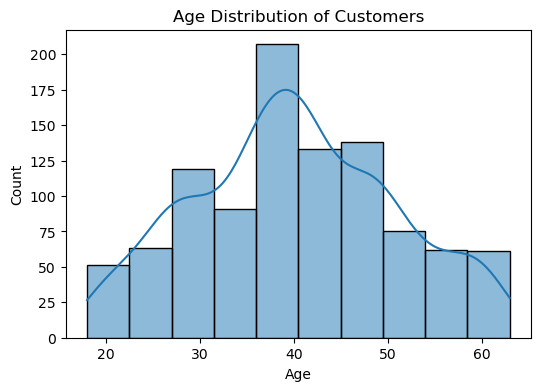

In [63]:
#frequent data so I use histogram
#Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()



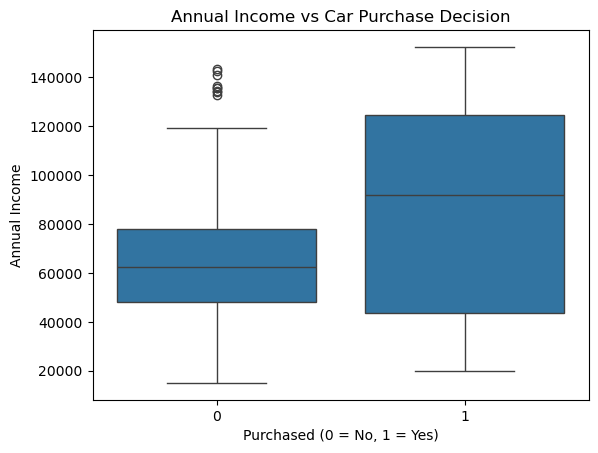

In [52]:

#Income vs Purchase
sns.boxplot(x='Purchased', y='AnnualSalary', data=df)
plt.title('Annual Income vs Car Purchase Decision')
plt.xlabel('Purchased (0 = No, 1 = Yes)')
plt.ylabel('Annual Income')
plt.show()



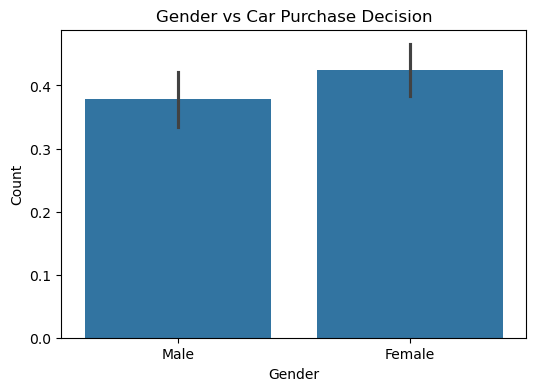

In [53]:
#Gender vs Purchase
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Purchased', data=df)
plt.title('Gender vs Car Purchase Decision')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

<h4>Clean Your Data</h4>

Here we handle missing values, drop irrelevant columns, and encode text data.

Explanations:

CustomerID and Name are removed because they don’t affect buying decisions.

Gender is mapped to 0/1 since Logistic Regression requires numeric data.

Missing rows are dropped to prevent training issues.

In [54]:
# Remove unnecessary columns
df = df.drop(columns=['User ID'])


df.replace('Male', 0, inplace=True)
df.replace('Female', 1, inplace=True)


df.dropna(axis=0, inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_16860\1536683816.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('Female', 1, inplace=True)


In [55]:
# Define features and target
X = df.drop('Purchased', axis=1)
y = df['Purchased']

<h4>Train and Test data</h4>

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=87)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

<h4>Part 7 – Evaluate Your Model</h4>

In [57]:
#Predicting the results
predictions = model.predict( X_test)
model.score(X_test, y_test)



0.7733333333333333

In [58]:
predictions = model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.74      0.92      0.82       169
           1       0.85      0.58      0.69       131

    accuracy                           0.77       300
   macro avg       0.80      0.75      0.76       300
weighted avg       0.79      0.77      0.76       300



In [59]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Gender        1000 non-null   int64
 1   Age           1000 non-null   int64
 2   AnnualSalary  1000 non-null   int64
dtypes: int64(3)
memory usage: 23.6 KB


<h4>Test Model</h4>

In [60]:
myTest = {
        'Gender':[1],     #1=female, 0=male
        'Age':[45],  
        'AnnualSalary':[233333]
       }
df = pd.DataFrame(myTest)
print(model.predict(df))

[1]
